# Experiment 8 — Computational Cost and Efficiency Trade-Offs

This notebook investigates the computational cost associated with different machine learning models under varying preprocessing conditions.

The purpose of the experiment is to examine how predictive performance relates to computational efficiency and whether improvements in preprocessing can alter the trade-off between model complexity and resource consumption.

The experiment compares:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

while measuring:
- training time,
- prediction time,
- and overall efficiency ratios.

Personally, I find this experiment particularly important because discussions of machine learning performance often focus almost exclusively on predictive metrics while overlooking computational cost. In practice, however, training efficiency, inference speed, and implementation complexity can be just as important as marginal performance improvements, especially in real-world deployment settings.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Importing the Experimental Framework

The notebook imports the centralized modules responsible for dataset loading, experiment execution, visualization, and result saving.

In [2]:
from src.data.load_data import (
    load_adult_dataset
)

from src.experiments.computational_cost import (
    run_computational_cost_experiment
)

from src.visualization.plots import (
    plot_efficiency_ratio,
    plot_training_time
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Running the Computational Cost Experiment

The experiment is executed through the centralized computational cost experiment module in order to ensure consistent preprocessing, timing measurement, training, and evaluation procedures.

In [4]:
results_df = run_computational_cost_experiment(
    X,
    y
)

results_df


=== Raw ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...
Training MLP...



=== Cleaned ===
Training Logistic Regression...


Training Decision Tree...


...


=== Engineered ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...


Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc,training_time_seconds,prediction_time_seconds,efficiency_ratio
0,Raw,Logistic Regression,0.782782,0.406267,0.626715,38.226836,0.012309,0.010628
1,Raw,Decision Tree,0.817586,0.622937,0.753165,0.324224,0.012631,1.921319
2,Raw,Naive Bayes,0.797113,0.421483,0.834841,0.106056,0.015471,3.974139
3,Raw,MLP,0.814822,0.511477,0.814207,3.472934,0.012120,0.147275
4,Cleaned,Logistic Regression,0.806940,0.676501,0.904395,11.687064,0.015433,0.057885
5,Cleaned,Decision Tree,0.817177,0.621931,0.752456,0.320275,0.011909,1.941866
6,Cleaned,Naive Bayes,0.620432,0.537425,0.828695,0.097530,0.012971,5.510376
7,Cleaned,MLP,0.834272,0.658799,0.884180,24.723756,0.013497,0.026646
8,Engineered,Logistic Regression,0.797113,0.665880,0.898428,12.278854,0.013110,0.054230
9,Engineered,Decision Tree,0.815334,0.613373,0.745864,10.016598,0.012593,0.061236


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [5]:
save_metrics(
    results_df,
    "computational_cost_results.csv"
)

Metrics saved to: ../results/metrics/computational_cost_results.csv


## Efficiency Ratio Visualization

The following figure compares the efficiency ratio across preprocessing levels and model types.

The efficiency ratio is calculated as predictive performance relative to training cost.

Plot saved to: ../results/plots/efficiency_ratio_comparison.png


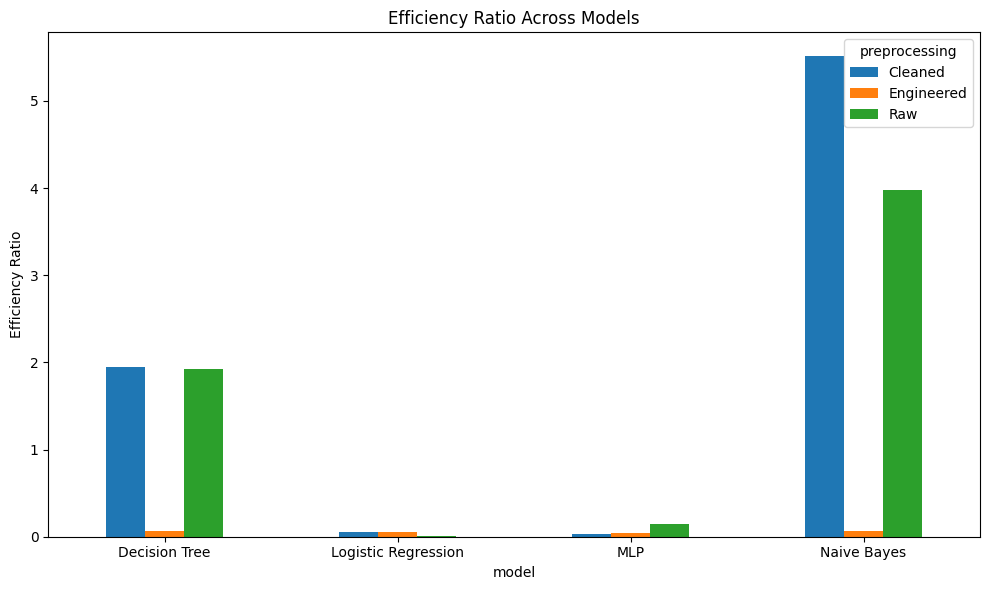

In [6]:
plot_efficiency_ratio(
    results_df,
    filename="efficiency_ratio_comparison.png"
)

## Training Time Visualization

The following figure compares training time across preprocessing levels and model types.

Plot saved to: ../results/plots/training_time_comparison.png


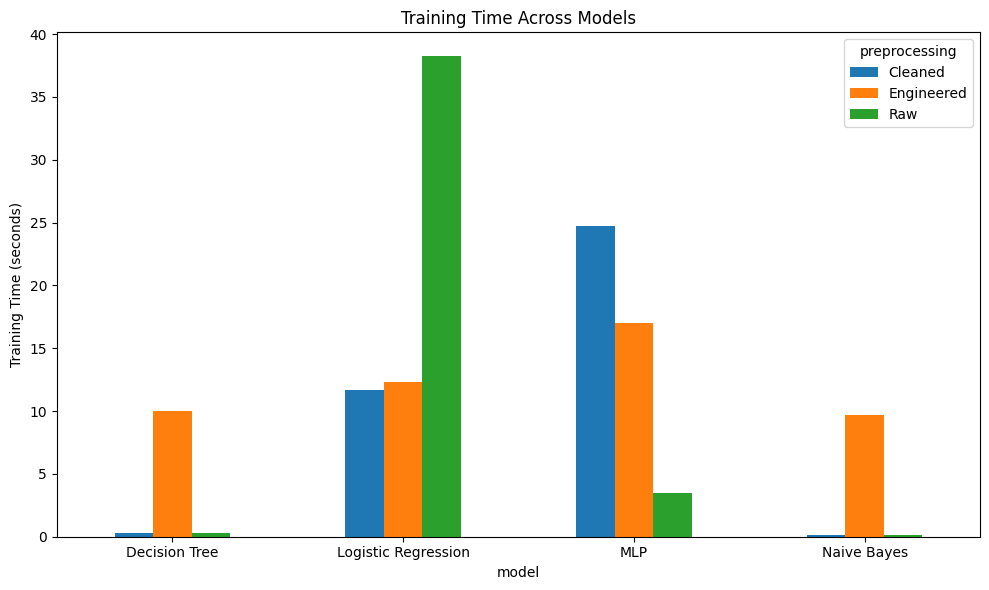

In [7]:
plot_training_time(
    results_df,
    filename="training_time_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [8]:
summary_table = save_summary_table(
    results_df,
    metric="efficiency_ratio",
    filename="computational_cost_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/computational_cost_summary_table.csv


,model,preprocessing,efficiency_ratio
0,Decision Tree,Cleaned,1.941866
1,Decision Tree,Engineered,0.061236
2,Decision Tree,Raw,1.921319
3,Logistic Regression,Cleaned,0.057885
4,Logistic Regression,Engineered,0.054230
5,Logistic Regression,Raw,0.010628
6,MLP,Cleaned,0.026646
7,MLP,Engineered,0.039361
8,MLP,Raw,0.147275
9,Naive Bayes,Cleaned,5.510376


## Interpretation of Computational Cost Results

The computational cost experiment reveals substantial differences in efficiency, scalability, and resource consumption across models and preprocessing conditions.

One of the clearest findings is that higher model complexity does not necessarily translate into proportionally higher predictive gains relative to computational cost. In several cases, comparatively simple models achieve competitive predictive performance while requiring substantially fewer computational resources.

Logistic Regression demonstrates an especially interesting trade-off pattern. Although predictive performance remains relatively strong under cleaned preprocessing conditions, training time under raw preprocessing becomes substantially higher. This suggests that preprocessing quality may influence not only predictive performance but also optimization stability and convergence efficiency.

The Multi-Layer Perceptron (MLP) consistently requires the greatest computational resources overall, particularly under cleaned preprocessing conditions. At the same time, engineered preprocessing improves both predictive performance and relative efficiency, suggesting that improved representation quality may partially reduce the computational burden associated with learning complex feature relationships directly from the data.

Naive Bayes demonstrates extremely strong computational efficiency due to its comparatively simple probabilistic structure. Although predictive performance remains lower than the strongest-performing models in several conditions, the model achieves exceptionally favorable efficiency ratios because of its minimal computational requirements.

Decision Trees also demonstrate relatively strong efficiency characteristics while maintaining stable predictive performance across preprocessing levels.

Personally, I found it particularly interesting how strongly preprocessing quality influenced computational efficiency itself. In several cases, better representations appeared to simplify the learning process enough to reduce optimization difficulty and improve overall efficiency.

Overall, the results increasingly support the broader motivation of the project: the relationship between preprocessing, inductive bias, and model complexity should not only be evaluated in terms of predictive performance, but also in relation to computational cost, scalability, and practical applicability.

## Computational Trade-Off Analysis

The computational cost experiment highlights an important trade-off between predictive performance and computational efficiency.

Several models achieve strong predictive performance while requiring substantially different computational resources. In particular, Naive Bayes and Decision Trees demonstrate extremely strong efficiency characteristics despite comparatively simpler inductive biases.

In contrast, the Multi-Layer Perceptron frequently achieves some of the strongest predictive performance overall, but also requires substantially greater computational resources during training.

Personally, I found it especially interesting that preprocessing quality appeared to influence computational efficiency itself. In several cases, better representation quality reduced optimization difficulty enough to improve both predictive performance and relative efficiency simultaneously.

These findings suggest that model selection in practical machine learning should not only consider predictive performance, but also computational cost, scalability, interpretability, and deployment constraints.